In [2]:
import json
import time

import numpy as np
import scipy.sparse as sp
from problems import Problem_sparse
from bounds.primary.truth import truth
from problems import solve
import seaborn as sns
import os
from mip import *
from pathlib import Path
import json
from ipywidgets import widgets

In [2]:
folder = "/Users/gderval/Downloads/benchmark/"
files = [x for x in os.listdir(folder) if x.endswith(".mps.gz")]

len(files), files

(240,
 ['blp-ic98.mps.gz',
  'dws008-01.mps.gz',
  'radiationm18-12-05.mps.gz',
  'bab2.mps.gz',
  'blp-ar98.mps.gz',
  'decomp2.mps.gz',
  'p200x1188c.mps.gz',
  'netdiversion.mps.gz',
  'trento1.mps.gz',
  'neos-5049753-cuanza.mps.gz',
  'neos8.mps.gz',
  'dano3_5.mps.gz',
  'supportcase6.mps.gz',
  'cvs16r128-89.mps.gz',
  'piperout-27.mps.gz',
  'neos-5093327-huahum.mps.gz',
  'neos-950242.mps.gz',
  'neos17.mps.gz',
  'k1mushroom.mps.gz',
  'drayage-100-23.mps.gz',
  'chromaticindex512-7.mps.gz',
  'irp.mps.gz',
  'proteindesign121hz512p9.mps.gz',
  'neos-933966.mps.gz',
  'uct-subprob.mps.gz',
  'sorrell3.mps.gz',
  'neos-3627168-kasai.mps.gz',
  'rail02.mps.gz',
  'app1-1.mps.gz',
  'neos-960392.mps.gz',
  'academictimetablesmall.mps.gz',
  'ns1952667.mps.gz',
  'neos-5107597-kakapo.mps.gz',
  'glass-sc.mps.gz',
  'csched008.mps.gz',
  'sp97ar.mps.gz',
  'neos-3024952-loue.mps.gz',
  'rmatr100-p10.mps.gz',
  's100.mps.gz',
  'graphdraw-domain.mps.gz',
  '50v-10.mps.gz',
  'neos-

In [3]:
# Keep only small problems, the ones that can be solved in less than 5s
if os.path.exists("miplib_all_small.json"):
    all_problems = json.load(open("miplib_all_small.json"))
else:
    all_problems = []
    for filename in files:
        print(filename)
        mps = Model()
        mps.read(folder+filename)
        status = mps.optimize(max_seconds=5)
        if status == OptimizationStatus.OPTIMAL:
            all_problems.append(filename)
    json.dump(all_problems, open("miplib_all_small.json", "w"))
    

In [7]:
MODE = "INEQ"

def gen_random(filename, attempt_progress=None, time_progress=None, check_progress=None):
    g_start_time = time.time()
    mps = Model()
    mps.read(folder+filename)
    if check_progress is not None:
        check_progress.value = 0
    a_eq = []
    b_eq = []
    a_ineq = []
    b_ineq = []
    
    for ctr in mps.constrs:
        mul = -1 if ctr.expr.sense == ">" else 1
        if ctr.expr.sense == "=":
            a = a_eq
            b = b_eq
        else:
            a = a_ineq
            b = b_ineq
        ctr_idx = len(b)
        
        for var, val in ctr.expr.expr.items():
            a.append((ctr_idx, var.idx, val*mul))
        b.append(mul*ctr.rhs)
        
    for v in mps.vars:
        if v.ub < 1e20:
            a_ineq.append((len(b_ineq), v.idx, 1.0))
            b_ineq.append(v.ub)
        if v.lb > -1e20:
            a_ineq.append((len(b_ineq), v.idx, -1.0))
            b_ineq.append(-v.lb)
            
    c = np.zeros((1, len(mps.vars)))
    for var, val in mps.objective.expr.items():
        c[0,var.idx] = val
        
    csr_a_eq = sp.coo_array(([x[2] for x in a_eq], ([x[0] for x in a_eq], [x[1] for x in a_eq])), shape=(len(b_eq), len(mps.vars))).tocsr()
    csr_a_ineq = sp.coo_array(([x[2] for x in a_ineq], ([x[0] for x in a_ineq], [x[1] for x in a_ineq])), shape=(len(b_ineq), len(mps.vars))).tocsr()
    
    orig_a_eq = csr_a_eq
    orig_a_ineq = csr_a_ineq
    orig_b_eq = np.array(b_eq).reshape((-1, 1))
    orig_b_ineq = np.array(b_ineq).reshape((-1, 1))
    orig_c = c
    
    random = np.random.default_rng(122807528843841406)
    n_perturbated_ctrs = 100
    min_perturbation_ratio = 0.3
    max_perturbation_ratio = 0.5
    
    # first randomly select len(mps.ctrs)*ratio_ctrs constraints
    n_ctrs = csr_a_eq.shape[0] + csr_a_ineq.shape[0]
    
    FOUND_VALUES = []
    
    for itr in range(1000):
        if attempt_progress is not None:
            attempt_progress.value = itr+1
        if time_progress is not None:
            time_progress.value = time.time() - g_start_time
        if itr > 200 and len(FOUND_VALUES):
            break
        #print("START RUN", "CURRENT BEST", 0 if not FOUND_VALUES else FOUND_VALUES[-1][0])
        if MODE == "ALL":
            try:
                perturbated_cstrs = random.choice(n_ctrs, size=n_perturbated_ctrs, replace=False)
                perturbated_cstrs_eq = [x for x in perturbated_cstrs if x < csr_a_eq.shape[0]]
                perturbated_cstrs_ineq = [x-csr_a_eq.shape[0] for x in perturbated_cstrs if x >= csr_a_eq.shape[0]]
            except:
                continue
        elif MODE == "INEQ":
            try:
                perturbated_cstrs_eq = []
                perturbated_cstrs_ineq = random.choice(csr_a_ineq.shape[0], size=n_perturbated_ctrs, replace=False)
            except:
                continue
        elif MODE == "EQ":
            try:
                perturbated_cstrs_ineq = []
                perturbated_cstrs_eq = random.choice(csr_a_eq.shape[0], size=n_perturbated_ctrs, replace=False)
            except:
                continue
        else:
            raise Exception("Unknown mode")
        
        def separate(csr_array, perturbated_idx):
            perturbated_idx_set = set(perturbated_idx)
            not_perturbated_idx = [x for x in range(csr_array.shape[0]) if x not in perturbated_idx_set]
            return csr_array[not_perturbated_idx, :], csr_array[perturbated_idx, :]
        
        a1_eq, a2_eq = separate(orig_a_eq, perturbated_cstrs_eq)
        b1_eq, b2_eq = separate(orig_b_eq, perturbated_cstrs_eq)
        a1_ineq, a2_ineq = separate(orig_a_ineq, perturbated_cstrs_ineq)
        b1_ineq, b2_ineq = separate(orig_b_ineq, perturbated_cstrs_ineq)
    
        def compute_perturbation(csr_array, nb_perturbated_per_row=3):
            data = np.zeros_like(csr_array.data)
            for row in range(csr_array.shape[0]):
                nb = csr_array.indptr[row+1] - csr_array.indptr[row]
                perturbated = random.choice(nb, size=min(nb, nb_perturbated_per_row)) + csr_array.indptr[row]
                data[perturbated] = csr_array.data[perturbated] * random.uniform(min_perturbation_ratio, max_perturbation_ratio, size=min(nb, nb_perturbated_per_row)) * random.choice([-1, 1], size=min(nb, nb_perturbated_per_row))
            return sp.csr_array((data, csr_array.indices.copy(), csr_array.indptr.copy()), shape=csr_array.shape)
        
        d_eq = compute_perturbation(a2_eq)
        d_ineq = compute_perturbation(a2_ineq)
        
        problem = Problem_sparse(
                        a_1_eq=a1_eq,
                        b_1_eq=b1_eq,
                        a_1_ineq=a1_ineq,
                        b_1_ineq=b1_ineq,
                        a_2_eq=a2_eq,
                        b_2_eq=b2_eq,
                        d_eq=d_eq,
                        a_2_ineq=a2_ineq,
                        b_2_ineq=b2_ineq,
                        d_ineq=d_ineq,
                        c=c.transpose(),
                        minimize=mps.sense == "MIN",
                        range=(-1, 1),
                        var_types=[v.var_type for v in mps.vars])
        
        start_time = time.time()
        out = solve(problem, -1, maxtime=5, fail_on_timeout=True)
        end_time = time.time()
        if end_time - start_time > 5:
            print("Problem is too large (more than 5s per point, and is thus skipped)")
            return None
        if end_time - g_start_time > 120:
            print("Spent more than 120 secs looking, stop here")
            return None
        if np.isnan(out):
            continue
        out2 = solve(problem, 0, maxtime=5, fail_on_timeout=True)
        if np.isnan(out2):
            continue
        out3 = solve(problem, 1, maxtime=5, fail_on_timeout=True)
        if np.isnan(out3):
            continue
        
        max_diff = max(abs(out-out2), abs(out3-out2), abs(out-out3))
        diff_mid = np.abs(out2-(out+out3)/2)
        if max_diff > 1e-4:
            print(f"FOUND {out=}, {out2=}, {out3=}, {max_diff=}, {diff_mid=}")

            # checking time to compute 100 points
            # TIMEOUT = 500
            #
            #check_start = time.time()
            #space = np.linspace(-1, 1, 100)
            #out = []
            #for idx, i in enumerate(space):
            #    if check_progress is not None:
            #        check_progress.value = idx
            #    if time.time() - check_start > TIMEOUT:
            #        print("But too long to compute 100 points, skip")
            #        return None
            #    out.append(solve(problem, i, maxtime=(TIMEOUT+5-time.time()+check_start)))
            #return problem, out
            return problem

def get_folder_name(filename):
    suffix = ""
    if MODE == "INEQ":
        suffix = "_ineq"
    elif MODE == "EQ":
        suffix = "_eq"
    
    name = ".".join(filename.split(".")[:-2])
    f = f"example_problems/miplib/{name}{suffix}"
    return f

def check_if_done(filename):
    return os.path.exists(get_folder_name(filename))

def store_problem(filename, problem):
    f = get_folder_name(filename)
    os.mkdir(f)
    sp.save_npz(f"{f}/a_1_eq.npz", problem.a_1_eq)
    sp.save_npz(f"{f}/a_2_eq.npz", problem.a_2_eq)
    sp.save_npz(f"{f}/a_1_ineq.npz", problem.a_1_ineq)
    sp.save_npz(f"{f}/a_2_ineq.npz", problem.a_2_ineq)
    sp.save_npz(f"{f}/d_eq.npz", problem.d_eq)
    sp.save_npz(f"{f}/d_ineq.npz", problem.d_ineq)
    np.savez(f"{f}/b_1_eq.npz", problem.b_1_eq)
    np.savez(f"{f}/b_2_eq.npz", problem.b_2_eq)
    np.savez(f"{f}/b_1_ineq.npz", problem.b_1_ineq)
    np.savez(f"{f}/b_2_ineq.npz", problem.b_2_ineq)
    np.savez(f"{f}/c.npz", problem.c.transpose())
    json.dump(problem.var_types, open(f"{f}/vartypes.json", "w"))
    #json.dump({"truth_time": truth_time, "robust_time": robust_time, "delta": delta}, open(f"{f}/data.json", "w"))

In [8]:
instance_progress = widgets.IntProgress(
        value=0,
        min=0,
        max=len(all_problems),
        description='Progress:',
        bar_style='info', # 'success', 'info', 'warning', 'danger' or ''
        orientation='horizontal'
    )
attempt_progress = widgets.IntProgress(
        value=0,
        min=0,
        max=1000,
        description='Attempts:',
        bar_style='warning', # 'success', 'info', 'warning', 'danger' or ''
        orientation='horizontal'
    )
time_progress = widgets.FloatProgress(
    value=0,
    min=0,
    max=120,
    description='Timer:',
    bar_style='warning', # 'success', 'info', 'warning', 'danger' or ''
    orientation='horizontal'
)
check_progress = widgets.FloatProgress(
    value=0,
    min=0,
    max=101,
    description='Check:',
    bar_style='success', # 'success', 'info', 'warning', 'danger' or ''
    orientation='horizontal'
)

display(instance_progress)
display(attempt_progress)
display(time_progress)
display(check_progress)

DONE = False

if not DONE:
    for pidx, p in enumerate(all_problems):
        instance_progress.value = pidx+1
        if check_if_done(p):
            continue
        try:
            out = gen_random(p, attempt_progress=attempt_progress, time_progress=time_progress, check_progress=check_progress)
        except:
            out = None
        if out is None:
            continue
        best_problem = out
        #print(p, truth_time, robust_time, delta)
        #print("-------------------")
        #print("-------------------")
        #print("-------------------")
        store_problem(p, best_problem)


IntProgress(value=0, bar_style='info', description='Progress:', max=71)

IntProgress(value=0, bar_style='warning', description='Attempts:', max=1000)

FloatProgress(value=0.0, bar_style='warning', description='Timer:', max=120.0)

FloatProgress(value=0.0, bar_style='success', description='Check:', max=101.0)

Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Read MPS format model from file /Users/gderval/Downloads/benchmark/decomp2.mps.gz
Reading time = 0.10 seconds
decomp2: 10765 rows, 14387 columns, 64073 nonzeros
Problem is too large (more than 5s per point, and is thus skipped)
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Read MPS format model from file /Users/gderval/Downloads/benchmark/p200x1188c.mps.gz
Reading time = 0.01 seconds
p200x1188c: 1388 rows, 2376 columns, 4752 nonzeros


...

Problem is too large (more than 5s per point, and is thus skipped)
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Read MPS format model from file /Users/gderval/Downloads/benchmark/roll3000.mps.gz
Reading time = 0.01 seconds
roll3000: 2295 rows, 1166 columns, 29386 nonzeros
Problem is too large (more than 5s per point, and is thus skipped)
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Read MPS format model from file /Users/gderval/Downloads/benchmark/piperout-08.mps.gz
Reading time = 0.02 seconds
piperout-08: 14589 rows, 10399 columns, 44959 nonzeros
Set para

Spent more than 120 secs looking, stop here
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Read MPS format model from file /Users/gderval/Downloads/benchmark/h80x6320d.mps.gz
Reading time = 0.02 seconds
h80x6320d: 6558 rows, 12640 columns, 31521 nonzeros


Spent more than 120 secs looking, stop here
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Read MPS format model from file /Users/gderval/Downloads/benchmark/exp-1-500-5-5.mps.gz
Reading time = 0.01 seconds
exp-1-500-5-5: 550 rows, 990 columns, 1980 nonzeros
Spent more than 120 secs looking, stop here
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Read MPS format model from file /Users/gderval/Downloads/benchmark/neos-1171448.mps.gz
Reading time = 0.03 seconds
neos-1171448: 13206 rows, 4914 columns, 131859 nonzeros
FOUND out=-309.9315229864218, out2=-309.0, ou

Advanced basis not built.
Advanced basis not built.


Problem is too large (more than 5s per point, and is thus skipped)
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Read MPS format model from file /Users/gderval/Downloads/benchmark/markshare_4_0.mps.gz
Reading time = 0.01 seconds
markshare_4_0: 4 rows, 34 columns, 123 nonzeros
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Set parameter Username
Set parameter LicenseID to value 2600465
Academic license - for non-commercial use only - expires 2025-12-17
Read MPS format model from file /Users/gderval/Downloads/benchmark/n2seq36q.mps.gz
Reading time = 0.06 seconds
n2seq36q: 2565 rows, 22480 columns, 183292 nonzeros
Problem is too large (more than 5s per point, and is thus skipped)
Set paramet

In [3]:
all_problems = []
miplib_folder = Path("example_problems/miplib")
for file in os.listdir(miplib_folder):
    if os.path.isdir(miplib_folder / file):
        all_problems.append(file)

def load_miplib_problem(problem_name):
    folder = miplib_folder / problem_name
    a_1_eq = sp.csr_array(sp.load_npz(folder / "a_1_eq.npz"))
    b_1_eq = np.load(folder / "b_1_eq.npz")["arr_0"]
    a_2_eq = sp.csr_array(sp.load_npz(folder / "a_2_eq.npz"))
    b_2_eq = np.load(folder / "b_2_eq.npz")["arr_0"]
    a_1_ineq = sp.csr_array(sp.load_npz(folder / "a_1_ineq.npz"))
    b_1_ineq = np.load(folder / "b_1_ineq.npz")["arr_0"]
    a_2_ineq = sp.csr_array(sp.load_npz(folder / "a_2_ineq.npz"))
    b_2_ineq = np.load(folder / "b_2_ineq.npz")["arr_0"]
    d_eq = sp.csr_array(sp.load_npz(folder / "d_eq.npz"))
    d_ineq = sp.csr_array(sp.load_npz(folder / "d_ineq.npz"))
    c = np.load(folder / "c.npz")["arr_0"]
    var_types = json.load(open(folder / "vartypes.json"))

    problem = Problem_sparse(
        a_1_eq=a_1_eq,
        b_1_eq=b_1_eq,
        a_1_ineq=a_1_ineq,
        b_1_ineq=b_1_ineq,
        a_2_eq=a_2_eq,
        b_2_eq=b_2_eq,
        d_eq=d_eq,
        a_2_ineq=a_2_ineq,
        b_2_ineq=b_2_ineq,
        d_ineq=d_ineq,
        c=c.transpose(),
        minimize=True,
        range=(-1, 1),
        var_types=var_types)
    #problem.dual()

    return problem

len(all_problems)

31

In [4]:
from bounds.primary.coefficient_bound import coefficient_flat
from bounds.primary.lagrangian import bound_lagrangian_flat, bound_lagrangian_flat_coef

space = np.linspace(-1, 1, 100)

to_show = {}
for idx, problem_name in enumerate(all_problems):
    print(problem_name, idx)
    problem = load_miplib_problem(problem_name)
    start_time = time.time()
    out = truth(problem, [-1, 1])["bounds"][0]["bound"](space)
    
    bounds = {
        "coef_lb": coefficient_flat.lb(problem, [-1, 1])["bounds"][0]["bound"],
        "coef_ub": coefficient_flat.ub(problem, [-1, 1])["bounds"][0]["bound"],
        "lag_flat_lb": bound_lagrangian_flat.lb(problem, [-1, 1])["bounds"][0]["bound"],
        "lag_flat_coef_lb": bound_lagrangian_flat_coef.lb(problem, [-1, 1])["bounds"][0]["bound"],
    }
    
    end_time = time.time()
    to_show[problem_name] = (out, end_time - start_time, bounds)
    print("\tdone in ", end_time - start_time, bounds)

mzzv11_eq 0
	done in  417.6045010089874 {'coef_lb': Constant(value=-21722.000000000007, limits=(-1, 1)), 'coef_ub': Constant(value=-20510.0, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=array([-27953.85080432]), limits=(-1, 1)), Constant(value=array([-25582.6396085]), limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=array([-27562.74765097]), limits=(-1, 1)), Constant(value=array([-24777.85418499]), limits=(-1, 1))], limits=(-1, 1))}
app1-1_eq 1


	done in  19.735171794891357 {'coef_lb': Constant(value=-3.0, limits=(-1, 1)), 'coef_ub': None, 'lag_flat_lb': Maximize(objects=[Constant(value=-22.616676368768164, limits=(-1, 1)), Constant(value=-22.614909780272193, limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=-22.616676368768164, limits=(-1, 1)), Constant(value=-22.614909780272193, limits=(-1, 1))], limits=(-1, 1))}
nu25-pr12_ineq 2
	done in  106.14625883102417 {'coef_lb': Constant(value=53905.0, limits=(-1, 1)), 'coef_ub': Constant(value=54175.0, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=array([51540.17299132]), limits=(-1, 1)), Constant(value=array([50911.55455287]), limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=array([51909.24039849]), limits=(-1, 1)), Constant(value=array([50922.51225632]), limits=(-1, 1))], limits=(-1, 1))}
neos-2987310-joes_ineq 3
	done in  1425.319000005722 {'coef_lb': Constant(value=-607702988.2909052,

	done in  88.34655499458313 {'coef_lb': Constant(value=69.0, limits=(-1, 1)), 'coef_ub': Constant(value=70.0, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=4.891112741118374, limits=(-1, 1)), Constant(value=4.848855814805677, limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=4.891112741118374, limits=(-1, 1)), Constant(value=4.848855814805677, limits=(-1, 1))], limits=(-1, 1))}
mzzv11_ineq 6
	done in  28901.62118792534 {'coef_lb': Constant(value=-21748.0, limits=(-1, 1)), 'coef_ub': Constant(value=-21448.0, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=-22918.397282056303, limits=(-1, 1)), Constant(value=-22868.02083956215, limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=-22918.397282056307, limits=(-1, 1)), Constant(value=-22868.020839562145, limits=(-1, 1))], limits=(-1, 1))}
drayage-100-23_eq 7


	done in  4995.492987155914 {'coef_lb': Constant(value=103333.87407302856, limits=(-1, 1)), 'coef_ub': Constant(value=103658.13085556032, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=6138.8215267105425, limits=(-1, 1)), Constant(value=4226.91659359537, limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=6138.8215267105425, limits=(-1, 1)), Constant(value=4226.91659359537, limits=(-1, 1))], limits=(-1, 1))}
drayage-100-23_ineq 8


	done in  2035.3363552093506 {'coef_lb': Constant(value=92604.33208465578, limits=(-1, 1)), 'coef_ub': Constant(value=103333.87407302855, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=11714.141979217555, limits=(-1, 1)), Constant(value=11714.141979217547, limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=11714.141979217547, limits=(-1, 1)), Constant(value=11714.141979217547, limits=(-1, 1))], limits=(-1, 1))}
30n20b8_ineq 9
	done in  21579.089329242706 {'coef_lb': Constant(value=302.0, limits=(-1, 1)), 'coef_ub': Constant(value=453.0, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=array([-69.27390311]), limits=(-1, 1)), Constant(value=array([-131.77998759]), limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=1.5664076455877094, limits=(-1, 1)), Constant(value=23.88455994974531, limits=(-1, 1))], limits=(-1, 1))}
fastxgemm-n2r6s0t2_ineq 10
	done in  26038.703593969345 {'coef_l

...

	done in  28.280086994171143 {'coef_lb': Constant(value=-3.0, limits=(-1, 1)), 'coef_ub': None, 'lag_flat_lb': Maximize(objects=[Constant(value=-22.73154568310263, limits=(-1, 1)), Constant(value=-22.69981485503497, limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=-22.73154568310263, limits=(-1, 1)), Constant(value=-22.69981485503497, limits=(-1, 1))], limits=(-1, 1))}
neos-3381206-awhea_ineq 23
	done in  136.36509680747986 {'coef_lb': Constant(value=450.0, limits=(-1, 1)), 'coef_ub': Constant(value=453.0, limits=(-1, 1)), 'lag_flat_lb': Constant(value=array([409.14781851]), limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=414.3454314034533, limits=(-1, 1)), Constant(value=413.04997127354375, limits=(-1, 1))], limits=(-1, 1))}
physiciansched6-2_eq 24


	done in  407.78910994529724 {'coef_lb': Constant(value=47465.56611076229, limits=(-1, 1)), 'coef_ub': Constant(value=55897.85529547102, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=42083.283055381246, limits=(-1, 1)), Constant(value=43941.716944618805, limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=42083.283055381246, limits=(-1, 1)), Constant(value=43941.716944618805, limits=(-1, 1))], limits=(-1, 1))}
p200x1188c_eq 25


	done in  112.93998432159424 {'coef_lb': Constant(value=15078.0, limits=(-1, 1)), 'coef_ub': Constant(value=15550.0, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=array([177.60968201]), limits=(-1, 1)), Constant(value=array([-2431.33539727]), limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=5678.984303797469, limits=(-1, 1)), Constant(value=5677.75592365228, limits=(-1, 1))], limits=(-1, 1))}
swath1_eq 26
	done in  50.66680693626404 {'coef_lb': Constant(value=379.0712957499995, limits=(-1, 1)), 'coef_ub': Constant(value=379.149044200001, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=334.3780612999999, limits=(-1, 1)), Constant(value=334.4968580999999, limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=334.3780612999999, limits=(-1, 1)), Constant(value=334.4968580999999, limits=(-1, 1))], limits=(-1, 1))}
nursesched-sprint02_eq 27
	done in  211.83208298683167 {'coef_lb': Con

	done in  37.24986982345581 {'coef_lb': Constant(value=67.0, limits=(-1, 1)), 'coef_ub': None, 'lag_flat_lb': Maximize(objects=[Constant(value=array([-74.10680934]), limits=(-1, 1)), Constant(value=array([-94.23209182]), limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=3.7786984821171843, limits=(-1, 1)), Constant(value=6.860837111251034, limits=(-1, 1))], limits=(-1, 1))}
p200x1188c_ineq 29


	done in  43.603721141815186 {'coef_lb': Constant(value=15078.0, limits=(-1, 1)), 'coef_ub': Constant(value=16543.0, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=array([-32554.84208712]), limits=(-1, 1)), Constant(value=array([-23597.52674061]), limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=array([-32554.84208712]), limits=(-1, 1)), Constant(value=array([-23597.52674061]), limits=(-1, 1))], limits=(-1, 1))}
n5-3_ineq 30
	done in  83.45603609085083 {'coef_lb': Constant(value=8105.0, limits=(-1, 1)), 'coef_ub': Constant(value=8195.0, limits=(-1, 1)), 'lag_flat_lb': Maximize(objects=[Constant(value=array([-21283838.46872948]), limits=(-1, 1)), Constant(value=array([-23412101.70420937]), limits=(-1, 1))], limits=(-1, 1)), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=array([-17540847.7237042]), limits=(-1, 1)), Constant(value=array([-19442973.85221608]), limits=(-1, 1))], limits=(-1, 1))}


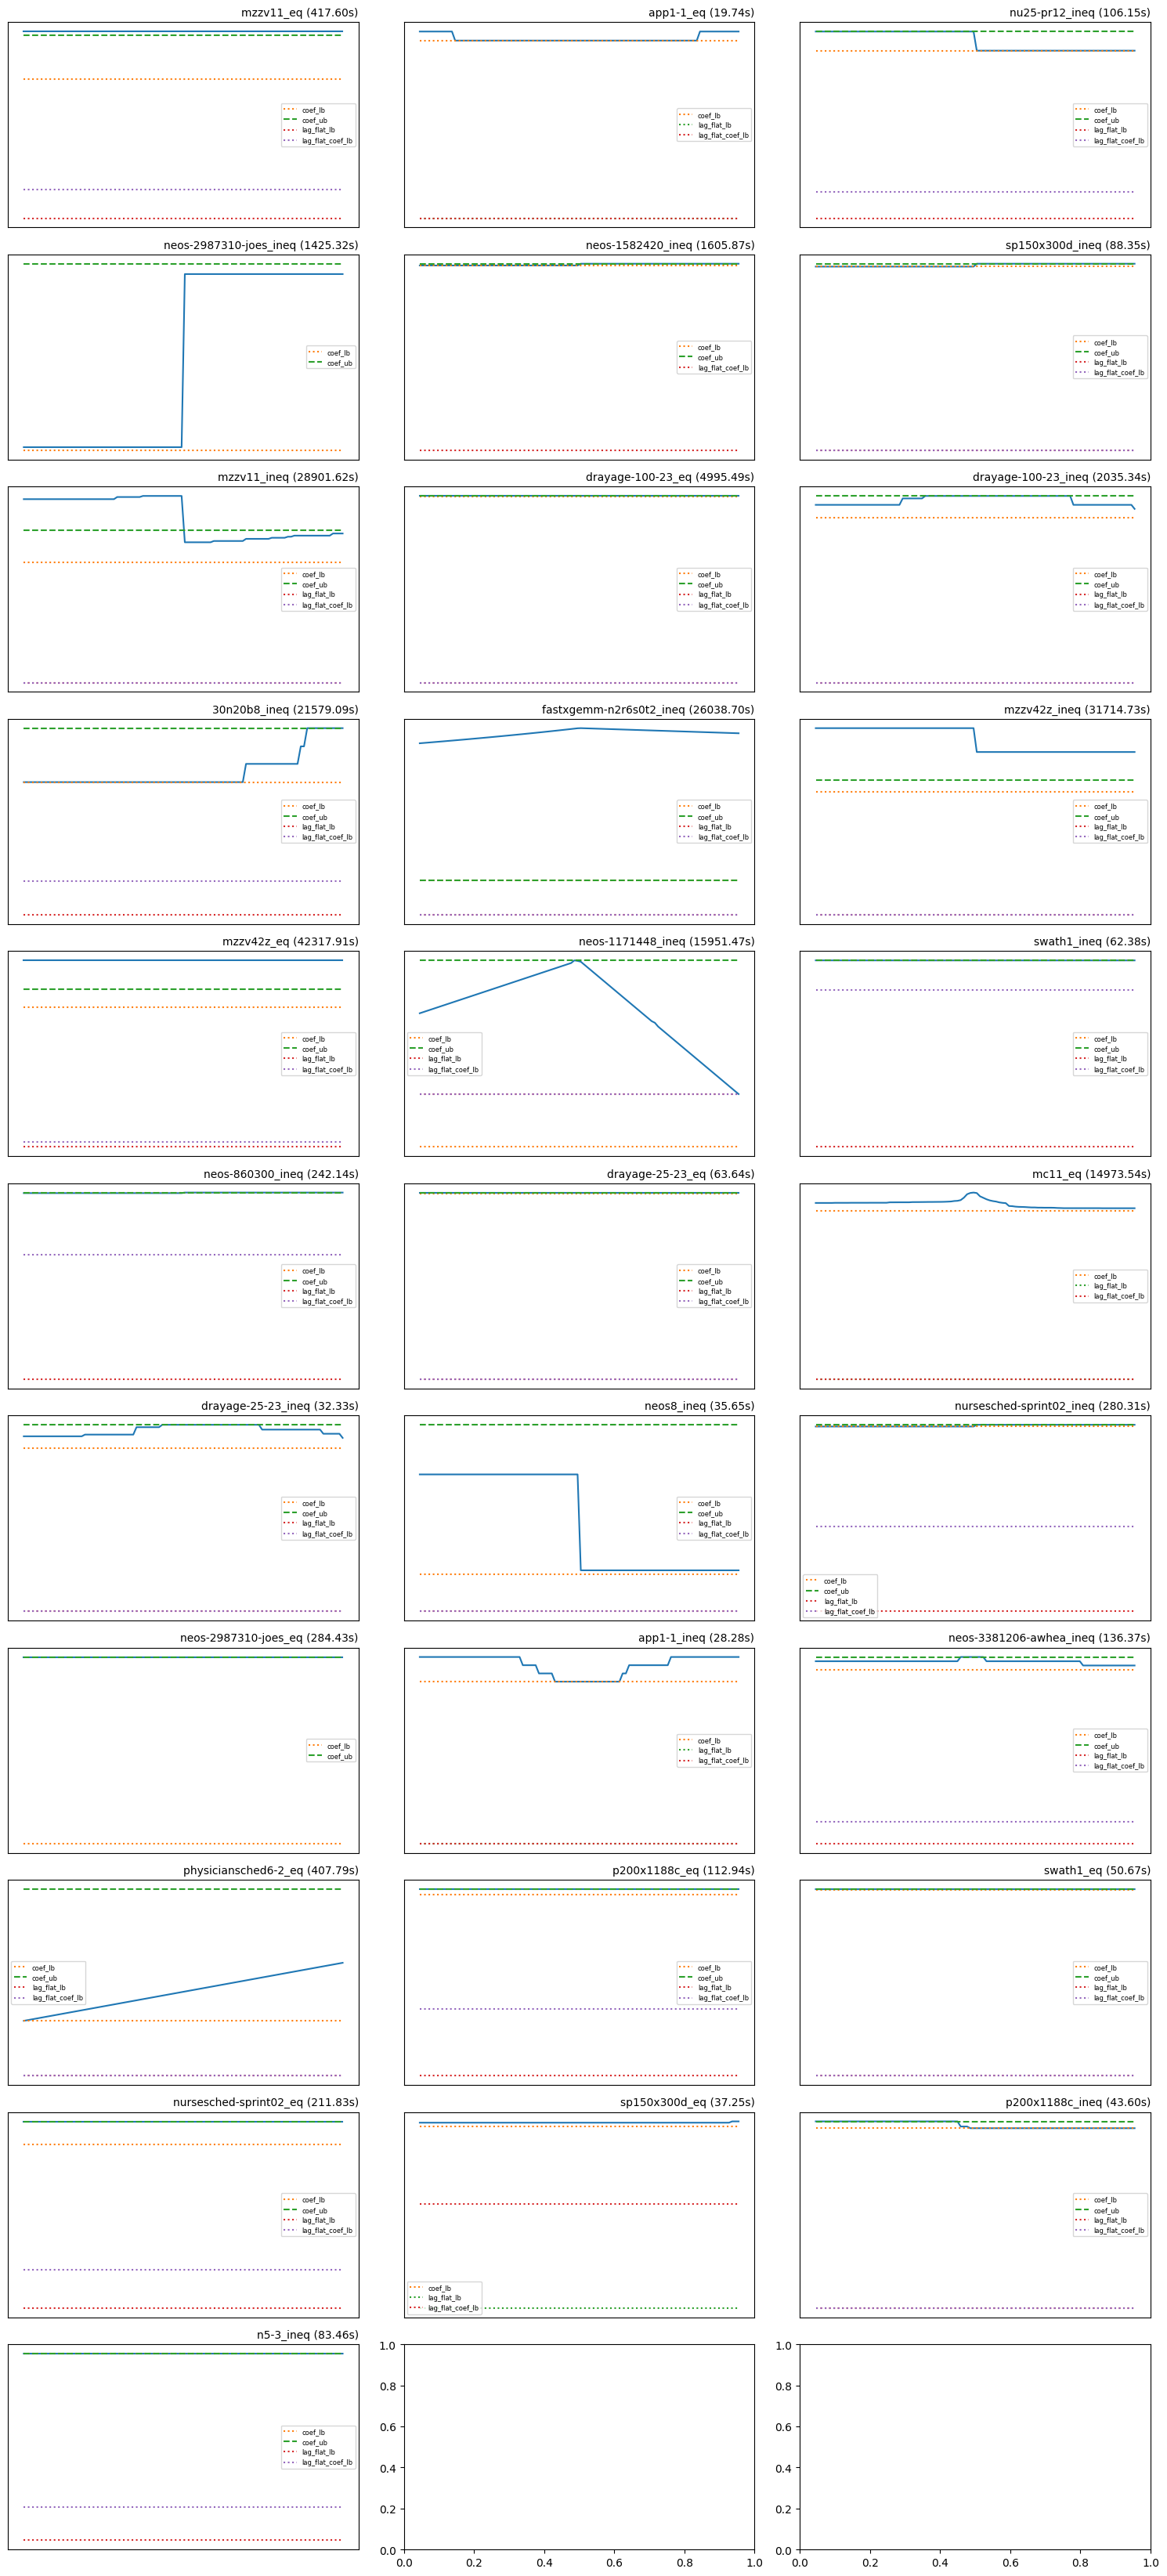

31
- coef_lb: 31 (100.00%)
- coef_ub: 27 (87.10%)
- lag_flat_lb: 28 (90.32%)
- lag_flat_coef_lb: 29 (93.55%)


In [6]:
import matplotlib.pyplot as plt
from math import ceil
from bounds.bound_utils import Error

n_cols = 3
n_rows = ceil(len(to_show) / n_cols)

n_valid = {}

fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
for idx, (problem_name, (out, timing, bounds)) in enumerate(to_show.items()):
    axs[idx // 3, idx % 3].plot(space, out)
    #axs[idx // 3, idx % 3].set_title(f"{problem_name} ({timing:.2f}s)")
    axs[idx // 3, idx % 3].set_xlabel("space")
    axs[idx // 3, idx % 3].set_ylabel("bound")

    for bname, b in bounds.items():
        if b is not None and not isinstance(b, Error):
            axs[idx // 3, idx % 3].plot(space, b(space), linestyle="dashed" if bname.endswith("_ub") else "dotted", label=bname)
            n_valid[bname] = n_valid.get(bname, 0) + 1

    axs[idx // 3, idx % 3].set_xlabel("")
    axs[idx // 3, idx % 3].set_ylabel("")
    axs[idx // 3, idx % 3].set_yticks([])
    axs[idx // 3, idx % 3].set_xticks([])
    
    axs[idx // 3, idx % 3].set_title(f"{problem_name} ({timing:.2f}s)", loc='right', position=(1.0, 0.1), fontsize=10)
    axs[idx // 3, idx % 3].legend(fontsize=6)
plt.tight_layout()
plt.show()
print(len(to_show))
for k, v in n_valid.items():
    print(f"- {k}: {v} ({v/len(to_show):.2%})")

In [ ]:
from bounds.primary.coefficient_bound import coefficient_flat
from bounds.primary.lagrangian import bound_lagrangian_bisegment, bound_lagrangian_bisegment_coef, bound_lagrangian_flat, bound_lagrangian_flat_coef

space = np.linspace(-1, 1, 100)

to_show_l = {}
for idx, problem_name in enumerate(all_problems):
    print(problem_name, idx)
    problem = load_miplib_problem(problem_name).linear()
    start_time = time.time()
    out = truth(problem, [-1, 1])["bounds"][0]["bound"](space)
    
    bounds = {
        "coef_lb": coefficient_flat.lb(problem, [-1, 1])["bounds"][0]["bound"],
        "coef_ub": coefficient_flat.ub(problem, [-1, 1])["bounds"][0]["bound"],
        "lag_bi_coef_lb": bound_lagrangian_bisegment_coef.lb(problem, [-1, 1])["bounds"][0]["bound"],
        "lag_bi_lb": bound_lagrangian_bisegment.lb(problem, [-1, 1])["bounds"][0]["bound"],
        "lag_flat_lb": bound_lagrangian_flat.lb(problem, [-1, 1])["bounds"][0]["bound"],
        "lag_flat_coef_lb": bound_lagrangian_flat_coef.lb(problem, [-1, 1])["bounds"][0]["bound"],
    }
    
    end_time = time.time()
    to_show_l[problem_name] = (out, end_time - start_time, bounds)
    print("\tdone in ", end_time - start_time, bounds)

    if idx >= 10:
        break

mas76.mps_ineq 0
	done in  0.8252968788146973 {'coef_lb': Constant(value=37280.66173554201, limits=(-1, 1)), 'coef_ub': Constant(value=39008.57880118782, limits=(-1, 1)), 'lag_bi_coef_lb': Maximize(objects=[Line(a=array([-25375.3702728]), b=array([12110.805424]), limits=(-1, 1)), Line(a=array([17210.24848124]), b=array([21623.42088186]), limits=(-1, 1))], limits=(-1, 1)), 'lag_bi_lb': Error(), 'lag_flat_lb': Error(), 'lag_flat_coef_lb': Maximize(objects=[Constant(value=array([-13264.5648488]), limits=(-1, 1)), Constant(value=array([4413.17240061]), limits=(-1, 1))], limits=(-1, 1))}
sp150x300d.mps_eq 1
	done in  0.7266011238098145 {'coef_lb': Constant(value=2.701129401486656, limits=(-1, 1)), 'coef_ub': None, 'lag_bi_coef_lb': Maximize(objects=[Line(a=array([-10.76698729]), b=array([-5.94841389]), limits=(-1, 1)), Line(a=array([5.25475951]), b=array([-1.33305863]), limits=(-1, 1))], limits=(-1, 1)), 'lag_bi_lb': Maximize(objects=[Line(a=array([-40.45933386]), b=array([-35.64076046]), l

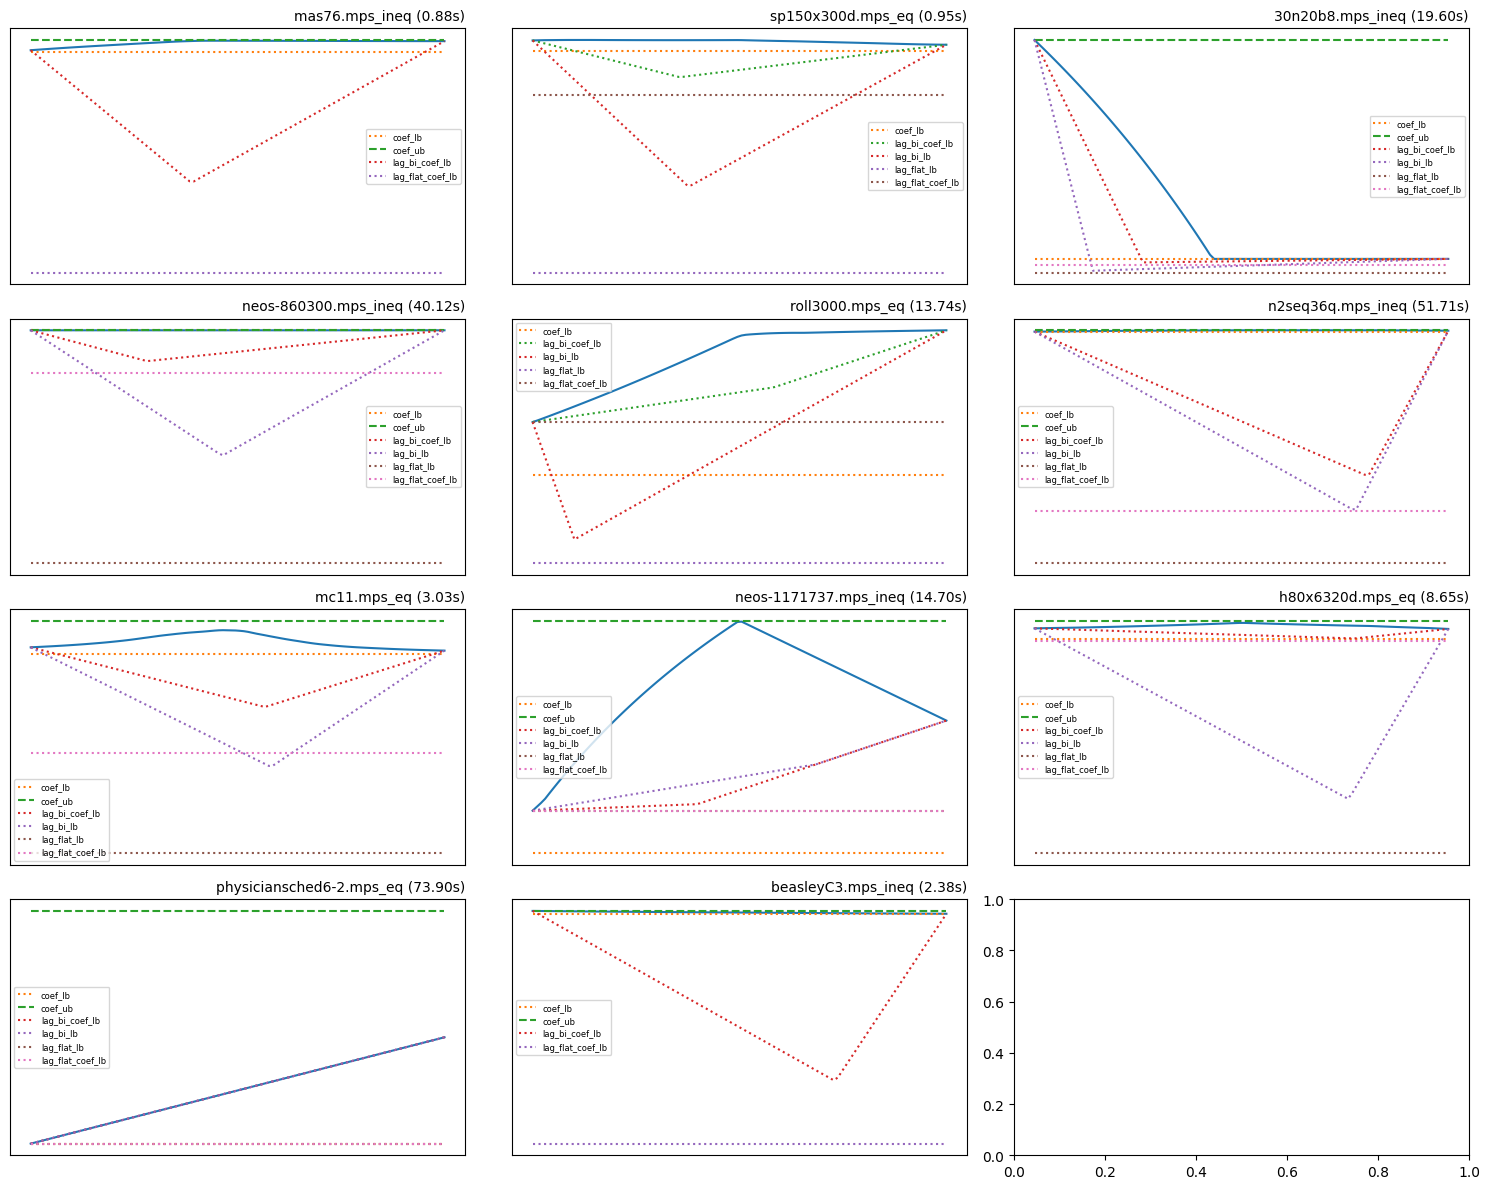

11
- coef_lb: 11 (100.00%)
- coef_ub: 9 (81.82%)
- lag_bi_coef_lb: 11 (100.00%)
- lag_flat_coef_lb: 11 (100.00%)
- lag_bi_lb: 9 (81.82%)
- lag_flat_lb: 9 (81.82%)


In [ ]:
import matplotlib.pyplot as plt
from math import ceil
from bounds.bound_utils import Error

n_cols = 3
n_rows = ceil(len(to_show_l) / n_cols)

n_valid = {}

fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
for idx, (problem_name, (out, timing, bounds)) in enumerate(to_show_l.items()):
    axs[idx // 3, idx % 3].plot(space, out)
    #axs[idx // 3, idx % 3].set_title(f"{problem_name} ({timing:.2f}s)")
    axs[idx // 3, idx % 3].set_xlabel("space")
    axs[idx // 3, idx % 3].set_ylabel("bound")

    for bname, b in bounds.items():
        if b is not None and not isinstance(b, Error):
            axs[idx // 3, idx % 3].plot(space, b(space), linestyle="dashed" if bname.endswith("_ub") else "dotted", label=bname)
            n_valid[bname] = n_valid.get(bname, 0) + 1

    axs[idx // 3, idx % 3].set_xlabel("")
    axs[idx // 3, idx % 3].set_ylabel("")
    axs[idx // 3, idx % 3].set_yticks([])
    axs[idx // 3, idx % 3].set_xticks([])
    
    axs[idx // 3, idx % 3].set_title(f"{problem_name} ({timing:.2f}s)", loc='right', position=(1.0, 0.1), fontsize=10)
    axs[idx // 3, idx % 3].legend(fontsize=6)
plt.tight_layout()
plt.show()
print(len(to_show_l))
for k, v in n_valid.items():
    print(f"- {k}: {v} ({v/len(to_show_l):.2%})")

In [7]:
n_up_valid

68